In [5]:
from dotenv import load_dotenv
import requests
import os
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
import asyncio, smtplib
from email.message import EmailMessage
load_dotenv( override=True )
MODEL_NAME = os.getenv("MODEL_NAME")

In [6]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


In [ ]:
# Here we go

def send_email(subject, text_body, html_body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [ ]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

In [9]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

Pushover user found and looks good
Pushover token found and looks good


In [10]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [11]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

In [12]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

Part 2 :- 

In [13]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [ ]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=MODEL_NAME)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=MODEL_NAME)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=MODEL_NAME)

In [15]:
result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Simplify SOC 2 readiness without adding headcount

Hi [First Name],

Reaching out because many teams find SOC 2 preparation becomes a time-consuming distraction from product and revenue work.

ComplAI helps companies get audit-ready faster with an AI-powered platform that streamlines evidence collection, control mapping, and ongoing compliance workflows — so your team can stay focused on building, not chasing spreadsheets.

If SOC 2 is on your roadmap this quarter, I’d welcome the chance to share how teams use ComplAI to reduce compliance overhead and prepare for audits with more confidence.

Would you be open to a brief conversation next week?

Best,  
[Your Name]  
ComplAI

In [16]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")

Subject: Reducing the burden of SOC 2 preparation

Hi [First Name],

I’m reaching out from ComplAI, where we help teams streamline SOC 2 compliance and prepare for audits with an AI-powered SaaS platform.

For many growing companies, compliance becomes a time-consuming distraction: policies, evidence collection, controls, and audit readiness all add up quickly. ComplAI is designed to reduce that burden by helping teams stay organized, move faster, and approach audits with more confidence.

If SOC 2 is on your roadmap this quarter, I’d welcome the opportunity to share how we support teams like yours.

Would you be open to a brief conversation next week?

Best,  
[Your Name]  
ComplAI


Subject: SOC 2 without the spreadsheet swamp

Hi {{FirstName}},

SOC 2 compliance has a funny way of turning smart teams into professional spreadsheet archaeologists.

At ComplAI, we help companies prepare for audits and stay compliant with a SaaS tool that uses AI to make the whole process a lot less pai

In [17]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=MODEL_NAME)

In [18]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")

Best sales email:
Subject: SOC 2 prep without the audit scramble

Hi [First Name] —

If SOC 2 is on your roadmap, ComplAI helps teams get audit-ready faster with less manual work.

We use AI to help you:
- map controls and evidence
- track gaps in real time
- stay organized for audit prep

The goal: fewer spreadsheet headaches, less back-and-forth, and a smoother path to certification.

Open to a quick 15-minute chat to see if it’s relevant?

Best,  
[Your Name]  
ComplAI


In [19]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

In [20]:
send_email_tool.params_json_schema

{'properties': {'subject': {'description': 'The subject of the email',
   'title': 'Subject',
   'type': 'string'},
  'text_body': {'description': 'The body of the email as plain text',
   'title': 'Text Body',
   'type': 'string'},
  'html_body': {'description': 'The HTML body of the email',
   'title': 'Html Body',
   'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [21]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=MODEL_NAME, tools=[send_email_tool], model_settings=require_tool)

In [22]:
message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

Final response:
Selected and sent: **“SOC 2 readiness without the usual chaos”**


In [23]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1 

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x00000264CD1A0EA0>, strict_json_schema=True, is_enabled=True)

In [24]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x00000264CC02C540>, strict_json_schema=True, is_enabled=True),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_2_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x00000264CD1C4720>, strict_json_schema=True, is_e

In [25]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=MODEL_NAME)

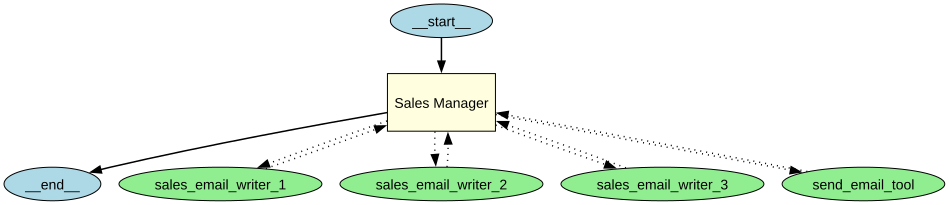

In [26]:
draw_graph(sales_manager)

In [27]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)